# Multi-Scenario Comparison — BC (single weather year)

Compares the policy/exclusion scenarios for the **same** weather year (2024), so all
differences are attributable to land-use, buffer, and grid-access assumptions rather
than interannual weather variability.

Scenarios (stores under `data/store/Canada/BC/`):

| Label | Scenario token | Meaning |
|---|---|---|
| BASELINE | `BASELINE` | Reference exclusions + buffers |
| POLICY | `strict_policy_aeroway_CPCAD_buffer` | Strict aeroway + CPCAD conservation buffers |
| S3 (No-Buffer) | `NO_BUFFERS` | Land-cover + slope only; all setback buffers = 0 (upper-bound technical potential) |
| S4 (Grid-Priority) | `BASELINE_GRID_RESTRICTED` | BASELINE + exclude cells beyond grid-distance limit |

Analysis is performed at the **cell** level (fixed grid), consistent with the rest of the paper.

## Configuration

In [11]:
WEATHER_YEAR = '2024'
RUN_DATE     = '20260603'   # run-date suffix on the 2024 scenario stores
COUNTRY_KWD  = 'Canada'
REGION_CODE  = 'BC'

# LCOE thresholds (USD/MWh) — same as the main analysis
SOLAR_LCOE_THRESHOLD = 90
WIND_LCOE_THRESHOLD  = 90

# Hours per year for energy conversion
HOURS_PER_YEAR = 8760

# Land-use competition shares (used for the haircut/competition view)
LANDUSE_COMP_SOLAR = 0.40
LANDUSE_COMP_WIND  = 0.60

# Scenario label -> scenario token in the store filename
SCENARIOS = {
    'Baseline'        : 'BASELINE',
    'No Buffers'    : 'NO_BUFFERS',
    'Baseline - Grid Restricted (within 50 km)': 'BASELINE_GRID_RESTRICTED',
    'Policy (restricted lands)'          : 'strict_policy_aeroway_CPCAD_buffer',
}
AGGREGATION_LEVEL = 'Province'

## Paths and imports

In [12]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore', category=UserWarning)

paper_resources = Path.cwd()
root = paper_resources.parent.parent
print('Root           :', root)
print('Paper resources:', paper_resources)

# Optional: use the project's Elsevier matplotlib style if present.
style = root / 'RES' / 'visual_styles' / 'elsevier.mplstyle'
if style.exists():
    try:
        plt.style.use(str(style))
    except Exception:
        pass

RUN_ID_TPL = f'{{token}}_{WEATHER_YEAR}_{RUN_DATE}'
store_dir  = paper_resources / f'data/store/{COUNTRY_KWD}/{REGION_CODE}'
if not store_dir.exists():
    store_dir = root / f'data/store/{COUNTRY_KWD}/{REGION_CODE}'
print('Store dir      :', store_dir)

results_dir = paper_resources / f'results/{COUNTRY_KWD}/{REGION_CODE}/scenarios_{WEATHER_YEAR}'
vis_dir     = paper_resources / f'vis/{COUNTRY_KWD}/{REGION_CODE}/scenarios_{WEATHER_YEAR}'
results_dir.mkdir(parents=True, exist_ok=True)
vis_dir.mkdir(parents=True, exist_ok=True)

Root           : /local-scratch/localhome/mei3/eliasinul/work/RESource
Paper resources: /local-scratch/localhome/mei3/eliasinul/work/RESource/notebooks/Publication_resources
Store dir      : /local-scratch/localhome/mei3/eliasinul/work/RESource/data/store/Canada/BC


## Load scenario stores
Prefers `RES.hdf5_handler.DataHandler`; falls back to `pandas.read_hdf` so the notebook runs without the RES package.

In [13]:
def load_cells(store_path: Path) -> pd.DataFrame:
    assert store_path.exists(), f'Store not found: {store_path}'
    try:
        import sys
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        from RES.hdf5_handler import DataHandler
        return DataHandler(store_path, show_structure=False).from_store('cells')
    except Exception:
        return pd.read_hdf(store_path, 'cells')

scenario_cells = {}
for label, token in SCENARIOS.items():
    run_id = RUN_ID_TPL.format(token=token)
    store  = store_dir / f'resources_{COUNTRY_KWD}_{REGION_CODE}_{run_id}.h5'
    try:
        cells = load_cells(store)
        scenario_cells[label] = cells
        print(f'\u2713 {label:18s} {len(cells):>6,} cells  <- {store.name}')
    except Exception as e:
        print(f'\u2717 {label:18s} could not load {store.name}: {e}')

✓ Baseline            2,956 cells  <- resources_Canada_BC_BASELINE_2024_20260603.h5
✓ No Buffers          2,956 cells  <- resources_Canada_BC_NO_BUFFERS_2024_20260603.h5
✓ Baseline - Grid Restricted (within 50 km)  2,956 cells  <- resources_Canada_BC_BASELINE_GRID_RESTRICTED_2024_20260603.h5
✓ Policy (restricted lands)  2,956 cells  <- resources_Canada_BC_strict_policy_aeroway_CPCAD_buffer_2024_20260603.h5


## Accessible capacity per scenario
Accessible = cells with screening-level LCOE proxy below the technology threshold.

In [14]:
TECHS = ('solar', 'wind')
THRESH = {'solar': SOLAR_LCOE_THRESHOLD, 'wind': WIND_LCOE_THRESHOLD}

def accessible_table(scenario_cells: dict) -> pd.DataFrame:
    rows = []
    for label, cells in scenario_cells.items():
        row = {'scenario': label}
        for t in TECHS:
            lcoe_col = f'lcoe_{t}'
            cap_col  = f'potential_capacity_{t}'
            if lcoe_col not in cells.columns or cap_col not in cells.columns:
                row[f'{t}_total_GW'] = np.nan
                row[f'{t}_accessible_GW'] = np.nan
                continue
            total = cells[cap_col].sum() / 1e3
            acc   = cells.loc[cells[lcoe_col] <= THRESH[t], cap_col].sum() / 1e3
            row[f'{t}_total_GW'] = round(total, 3)
            row[f'{t}_accessible_GW'] = round(acc, 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('scenario')
    if 'BASELINE' in df.index:
        for t in TECHS:
            col = f'{t}_accessible_GW'
            base = df.loc['BASELINE', col]
            if base and not np.isnan(base):
                df[f'{t}_acc_delta_pct_vs_BASE'] = (100 * (df[col] - base) / base).round(1)
    return df

summary = accessible_table(scenario_cells)
summary.to_csv(results_dir / 'scenario_accessible_capacity.csv')
summary

,solar_total_GW,solar_accessible_GW,wind_total_GW,wind_accessible_GW
scenario,,,,
Baseline,195.925,12.793,426.387,47.164
No Buffers,201.216,13.586,447.171,50.077
Baseline - Grid Restricted (within 50 km),195.925,12.793,426.387,47.164
Policy (restricted lands),169.129,3.299,333.649,26.243


## Capacity supply curves — scenarios overlaid (per technology)

In [15]:
STYLE = {
    'Baseline'        : {'color': "#56D4D8", 'ls': '-', 'lw': 5, 'alpha': 0.6},
    'Policy (restricted lands)'          : {'color': '#E31A1C', 'ls': '-', 'lw': 1.4, 'alpha': 1},
    'No Buffers'    : {'color': "#6516CC", 'ls': '--', 'lw': 1.4, 'alpha': 1},
    'Baseline - Grid Restricted (within 50 km)': {'color': '#FF7F00', 'ls': '-.', 'lw': 1.4, 'alpha': 1},
}

def supply_curve(ax, cells, tech, label):
    lcoe_col, cap_col = f'lcoe_{tech}', f'potential_capacity_{tech}'
    if lcoe_col not in cells.columns or cap_col not in cells.columns:
        return
    d = cells[[lcoe_col, cap_col]].dropna().sort_values(lcoe_col)
    x = np.cumsum(d[cap_col].values) / 1e3  # GW
    st = STYLE.get(label, {'color': 'grey', 'ls': '-','lw': 1.4, 'alpha': 0.9})
    ax.step(x, d[lcoe_col].values, where='post', lw=st['lw'],
            color=st['color'], ls=st['ls'], alpha=st['alpha'], label=label)

def energy_supply_curve(ax, cells, tech, label):
    lcoe_col = f'lcoe_{tech}'
    cap_col  = f'potential_capacity_{tech}'
    cf_col   = f'{tech}_CF_mean'
    need = [lcoe_col, cap_col, cf_col]
    if any(c not in cells.columns for c in need):
        print(f'  skip {label}/{tech}: missing {[c for c in need if c not in cells.columns]}')
        return
    d = cells[need].dropna().sort_values(lcoe_col)
    energy_twh = d[cap_col].values * d[cf_col].values * HOURS_PER_YEAR / 1e6  # MWh -> TWh
    x = np.cumsum(energy_twh)
    st = STYLE.get(label, {'color': 'grey', 'ls': '-', 'lw': 1.4, 'alpha': 0.9})
    ax.step(x, d[lcoe_col].values, where='post', lw=st['lw'],
            color=st['color'], ls=st['ls'], alpha=st['alpha'], label=label)

Baseline 117 solar cells ≤90
No Buffers 117 solar cells ≤90
Baseline - Grid Restricted (within 50 km) 117 solar cells ≤90
Policy (restricted lands) 39 solar cells ≤90


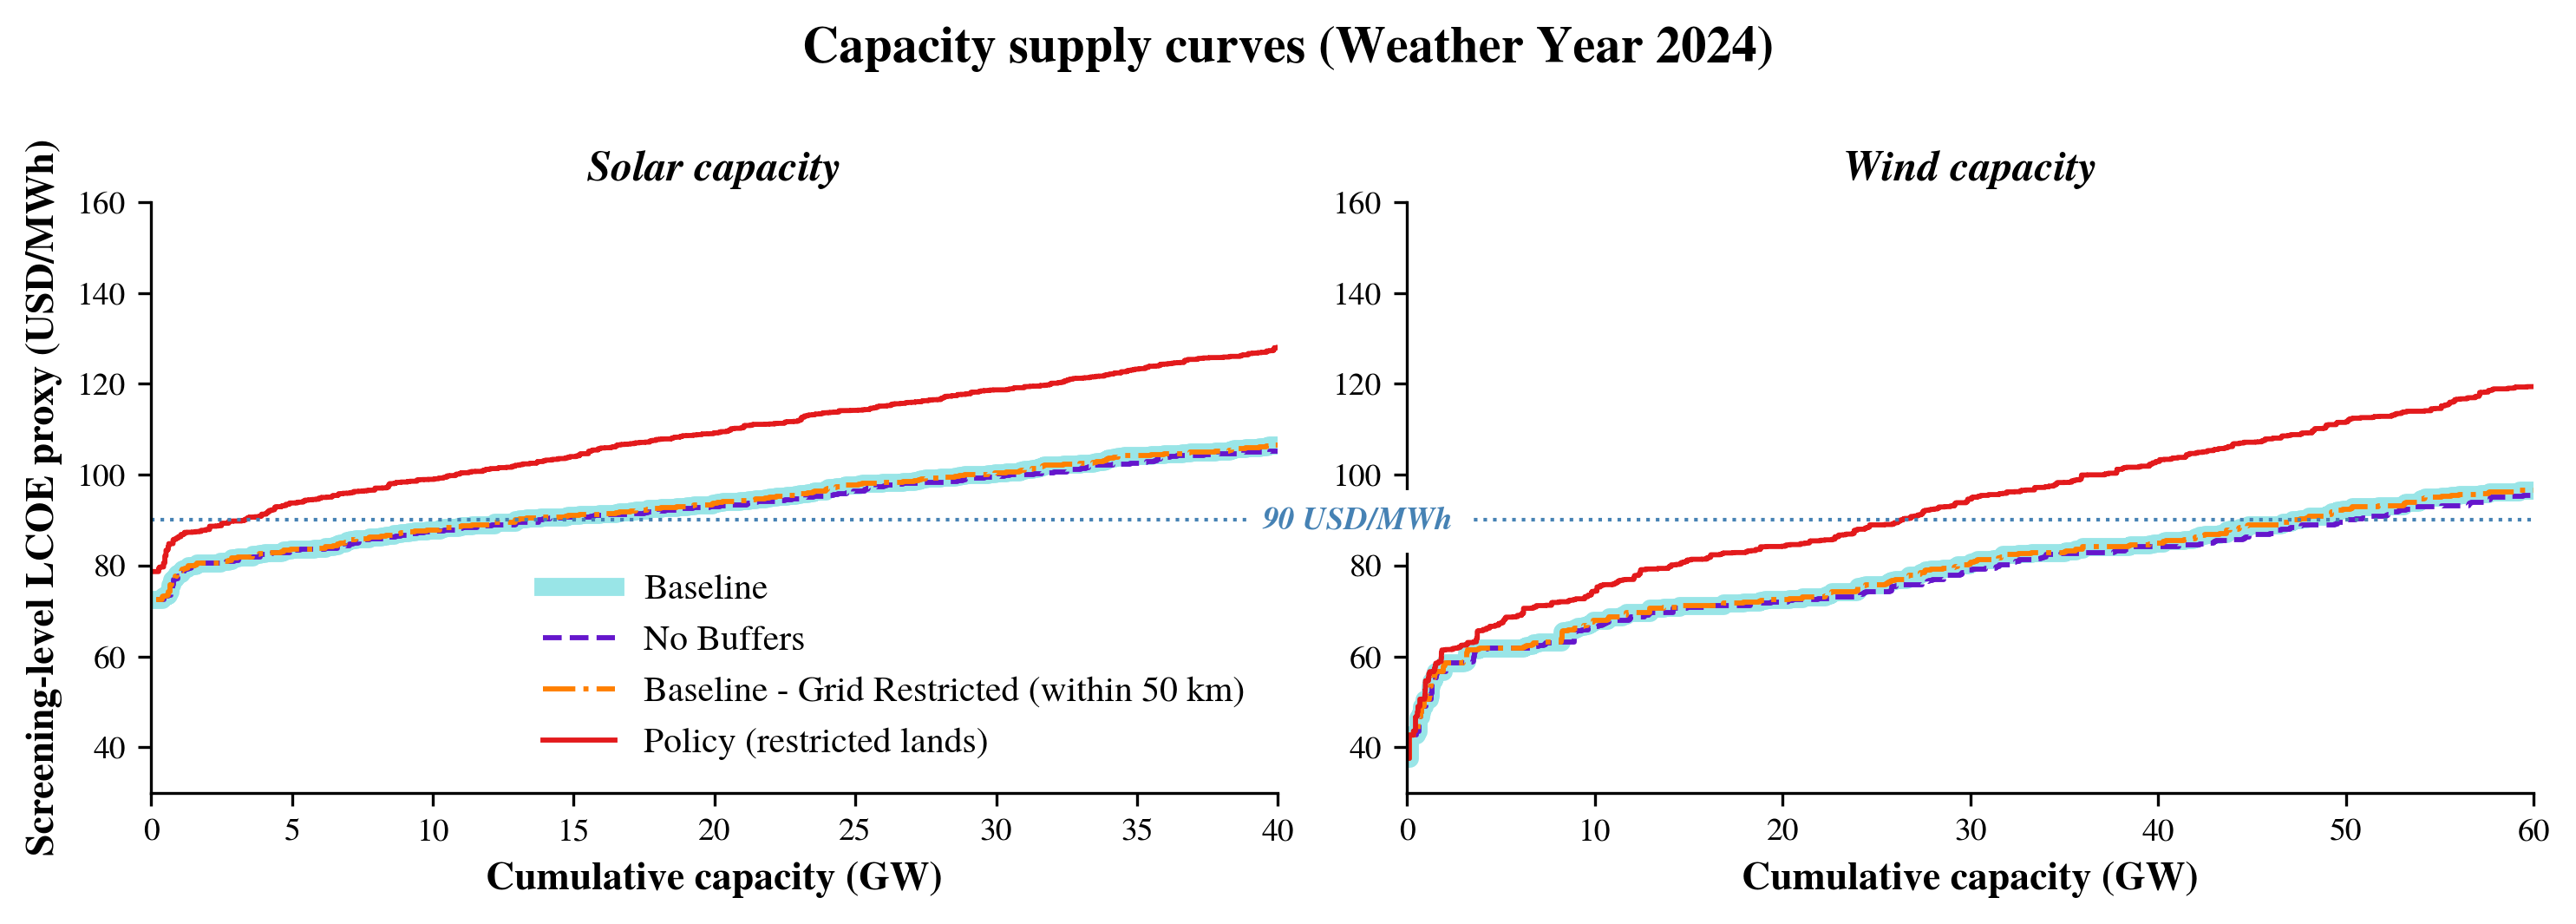

In [16]:
for k,c in scenario_cells.items(): print(k, (c['lcoe_solar']<=90).sum(), 'solar cells ≤90')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300,)
suptitle = f'Capacity supply curves (Weather Year {WEATHER_YEAR})'

fig.suptitle(suptitle, fontsize=14, y=1,fontweight='bold')
fig.text(0.49, 0.44, f'{THRESH[TECHS[0]]} USD/MWh', ha='left', va='bottom', fontsize=9,color='steelblue', backgroundcolor='white',style='italic', alpha=1,fontweight='bold')

for i, (ax, tech) in enumerate(zip(axes, TECHS)):
    for label, cells in scenario_cells.items():
        supply_curve(ax, cells, tech, label)
    ax.axhline(THRESH[tech], ls= 'dotted', lw=1, color='steelblue',alpha=1)
    ax.set_xlabel('Cumulative capacity (GW)',fontsize=11,fontweight='bold')
    ax.set_title(f'{tech.title()} capacity',style='italic',fontweight='bold')
    if i==0:
        ax.legend(frameon=False, fontsize=10, loc='lower right')
    ax.set_xlim(0, {'solar': 40, 'wind': 60}[tech])
    ax.set_ylim(30, 160)
    if i == 0:
        ax.set_ylabel('Screening-level LCOE proxy (USD/MWh)', fontsize=11,fontweight='bold')   # left axis only
    ## For different thresholds, we can adjust the annotation position accordingly. Here, we place it near the threshold line, and align it to the right for the first subplot and to the left for the second subplot.
    # if i==0:
    #     lcoe_annotation_xy=(0.99, THRESH[tech] / 160*0.8)  # position near the threshold line
    #     lcoe_annotation_ha='right'
    # else:
    #     lcoe_annotation_xy=(0.02,THRESH[tech] / 160*0.9)
    #     lcoe_annotation_ha='left'

        
    
    # ax.annotate(f'screening threshold {THRESH[tech]} USD/MWh',
    #             xy=lcoe_annotation_xy, xycoords='axes fraction',
    #             ha=lcoe_annotation_ha, va='top', fontsize=9, color='k', style='italic', alpha=0.9)

    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
fig.tight_layout()
fig.savefig(vis_dir / 'scenario_capacity_supply_curves.svg', dpi=300, bbox_inches='tight')


## Energy-budget supply curves — scenarios overlaid (per technology)
X axis is cumulative **annual energy** rather than capacity:
`energy (TWh) = potential_capacity (MW) \u00d7 {tech}_CF_mean \u00d7 8760 / 1e6`.
This reflects how much generation each scenario actually unlocks, weighting capacity by resource quality.

Baseline 117 solar cells ≤90
No Buffers 117 solar cells ≤90
Baseline - Grid Restricted (within 50 km) 117 solar cells ≤90
Policy (restricted lands) 39 solar cells ≤90


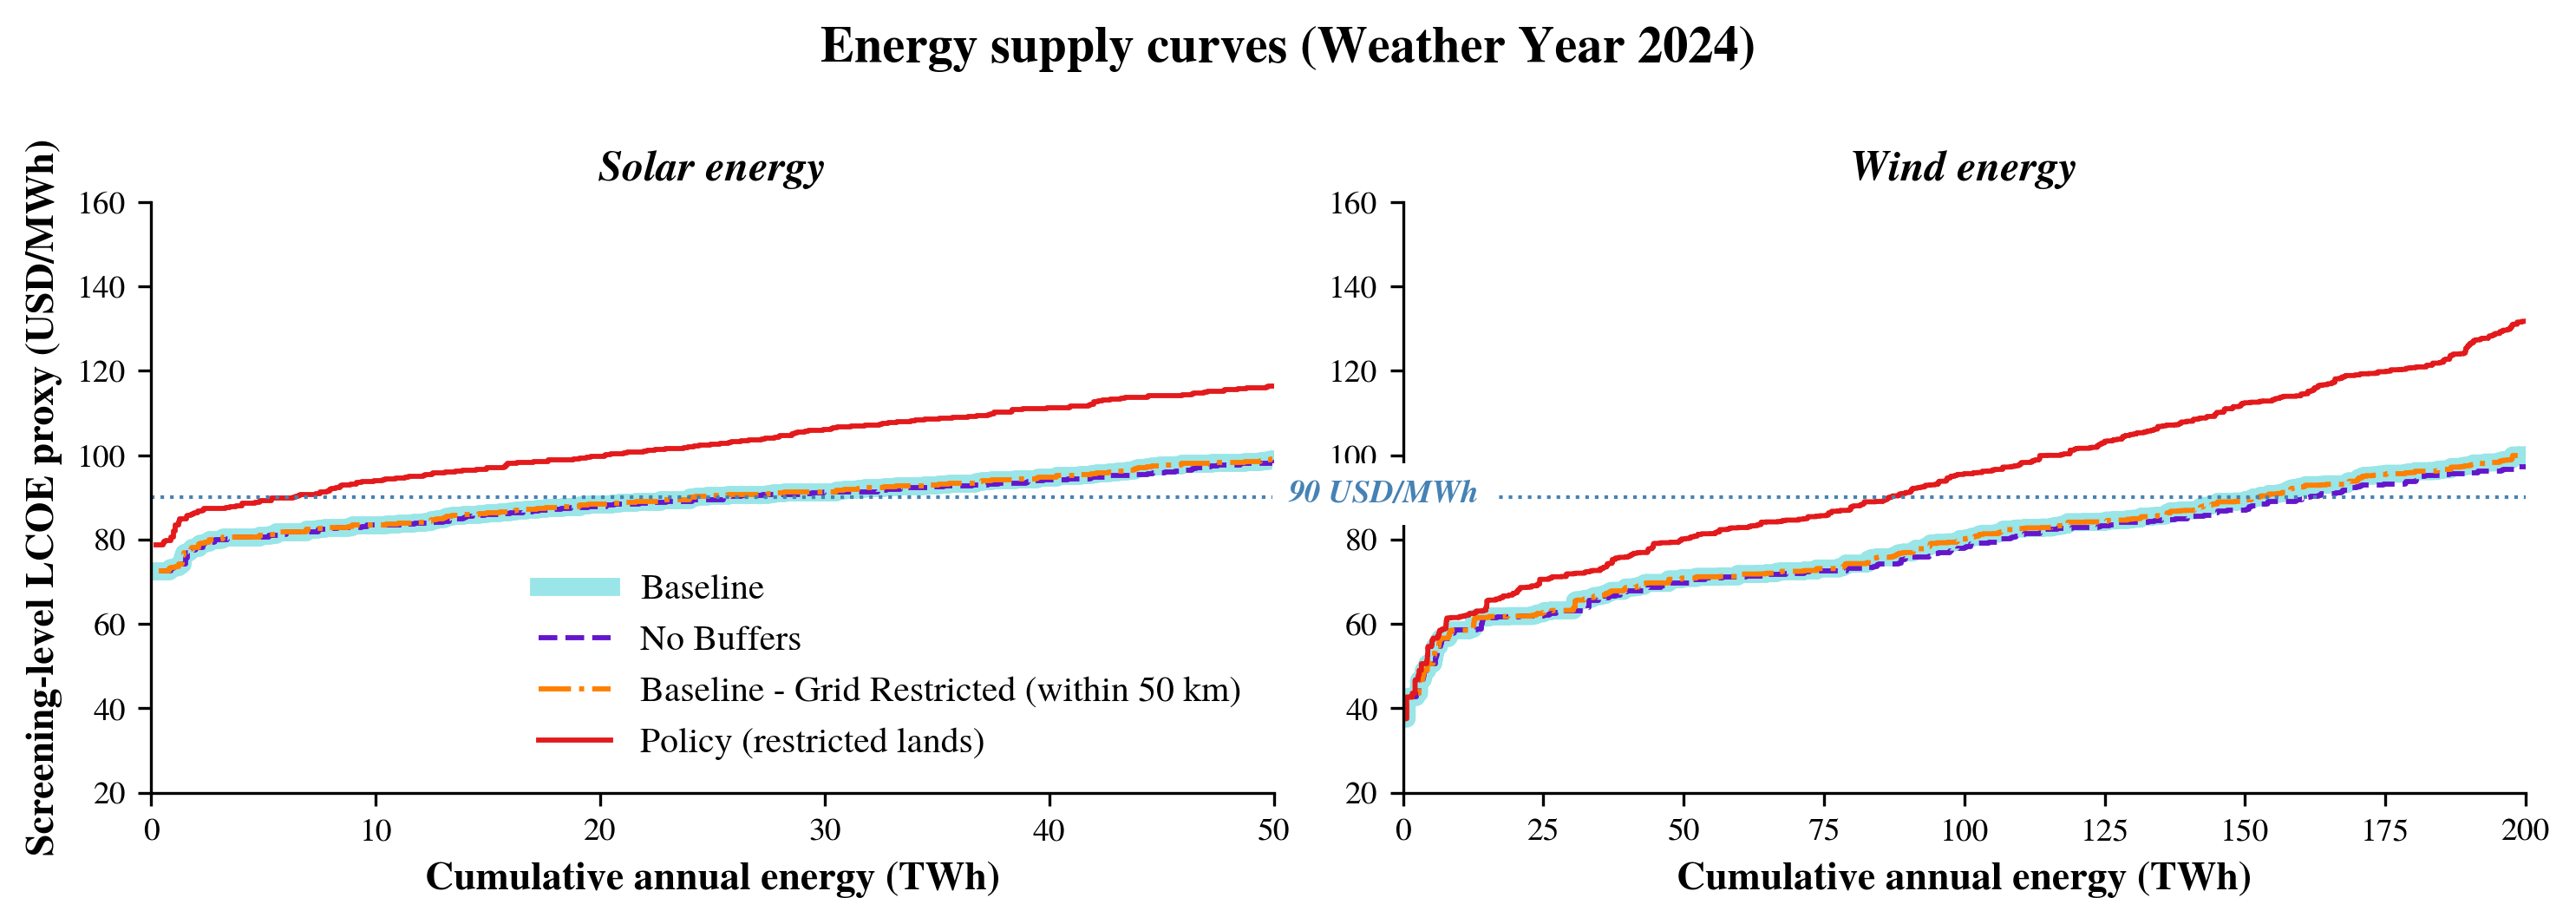

In [17]:
for k,c in scenario_cells.items(): print(k, (c['lcoe_solar']<=90).sum(), 'solar cells ≤90')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)
suptitle = f'Energy supply curves (Weather Year {WEATHER_YEAR})'

fig.suptitle(suptitle, fontsize=14, y=1,fontweight='bold')
## For common threshold annotation, we can place it as a figure-level text centered above the subplots. This way, it applies to both subplots without needing to annotate each one separately.
fig.text(0.5, 0.47, f'{THRESH[TECHS[0]]} USD/MWh', ha='left', va='bottom', fontsize=9,color='steelblue', backgroundcolor='white',style='italic', alpha=1,fontweight='bold')

for ax, tech in zip(axes, TECHS):
    i = TECHS.index(tech)
    for label, cells in scenario_cells.items():
        energy_supply_curve(ax, cells, tech, label)
    ax.axhline(THRESH[tech], ls=':', lw=1, color='steelblue',alpha=1)
    ax.set_xlabel('Cumulative annual energy (TWh)',fontsize=11,fontweight='bold')
    ax.set_title(f'{tech.title()} energy',style='italic',fontweight='bold')
    
    if i == 0:
        ax.set_ylabel('Screening-level LCOE proxy (USD/MWh)', fontsize=11,fontweight='bold')   # left axis only
    
    if i==0:
        ax.legend(frameon=False, fontsize=10, loc='lower right')
    
    ax.set_xlim(0, {'solar': 50, 'wind': 200}[tech])   # TWh — adjust per tech
    ax.set_ylim(20, 160)  # USD/MWh
    
    ### For multiple thresholds, we can adjust the annotation position accordingly. Here, we place it near the threshold line, and align it to the right for the first subplot and to the left for the second subplot.

    # if i==0:
    #     lcoe_annotation_xy=(0.99, THRESH[tech] / 160)  # position near the threshold line
    #     lcoe_annotation_ha='right'
    # else:
    #     lcoe_annotation_xy=(0.02,THRESH[tech] / 160)
    #     lcoe_annotation_ha='left'
    # ax.annotate(f'screening threshold {THRESH[tech]} USD/MWh',
    #             xy=lcoe_annotation_xy, xycoords='axes fraction',
    #             ha=lcoe_annotation_ha, va='top', fontsize=9, color='k', style='italic', alpha=0.9)
    # ax.annotate(f'Weather Year {WEATHER_YEAR}',
    #             xy=(0.05, 0.95), xycoords='axes fraction',
    #             ha='left', va='top', fontsize=9, color='k', style='italic', alpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
    
fig.tight_layout()
fig.savefig(vis_dir / 'scenario_energy_supply_curves.svg', dpi=300, bbox_inches='tight')
plt.show()



## Accessible energy per scenario (TWh)
Annual energy from cells below the LCOE threshold, per scenario.

In [18]:
def accessible_energy_table(scenario_cells: dict) -> pd.DataFrame:
    rows = []
    for label, cells in scenario_cells.items():
        row = {'scenario': label}
        for t in TECHS:
            lcoe_col, cap_col, cf_col = f'lcoe_{t}', f'potential_capacity_{t}', f'{t}_CF_mean'
            if any(c not in cells.columns for c in (lcoe_col, cap_col, cf_col)):
                row[f'{t}_accessible_TWh'] = np.nan
                continue
            sub = cells.loc[cells[lcoe_col] <= THRESH[t], [cap_col, cf_col]].dropna()
            twh = (sub[cap_col] * sub[cf_col] * HOURS_PER_YEAR / 1e6).sum()
            row[f'{t}_accessible_TWh'] = round(twh, 2)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('scenario')
    if 'BASELINE' in df.index:
        for t in TECHS:
            col = f'{t}_accessible_TWh'
            base = df.loc['BASELINE', col]
            if base and not np.isnan(base):
                df[f'{t}_energy_delta_pct_vs_BASE'] = (100 * (df[col] - base) / base).round(1)
    return df

energy_summary = accessible_energy_table(scenario_cells)
energy_summary.to_csv(results_dir / 'scenario_accessible_energy.csv')
energy_summary

,solar_accessible_TWh,wind_accessible_TWh
scenario,,
Baseline,23.75,151.51
No Buffers,25.23,160.56
Baseline - Grid Restricted (within 50 km),23.75,151.51
Policy (restricted lands),6.33,86.48


## Accessible-capacity and -energy bar charts

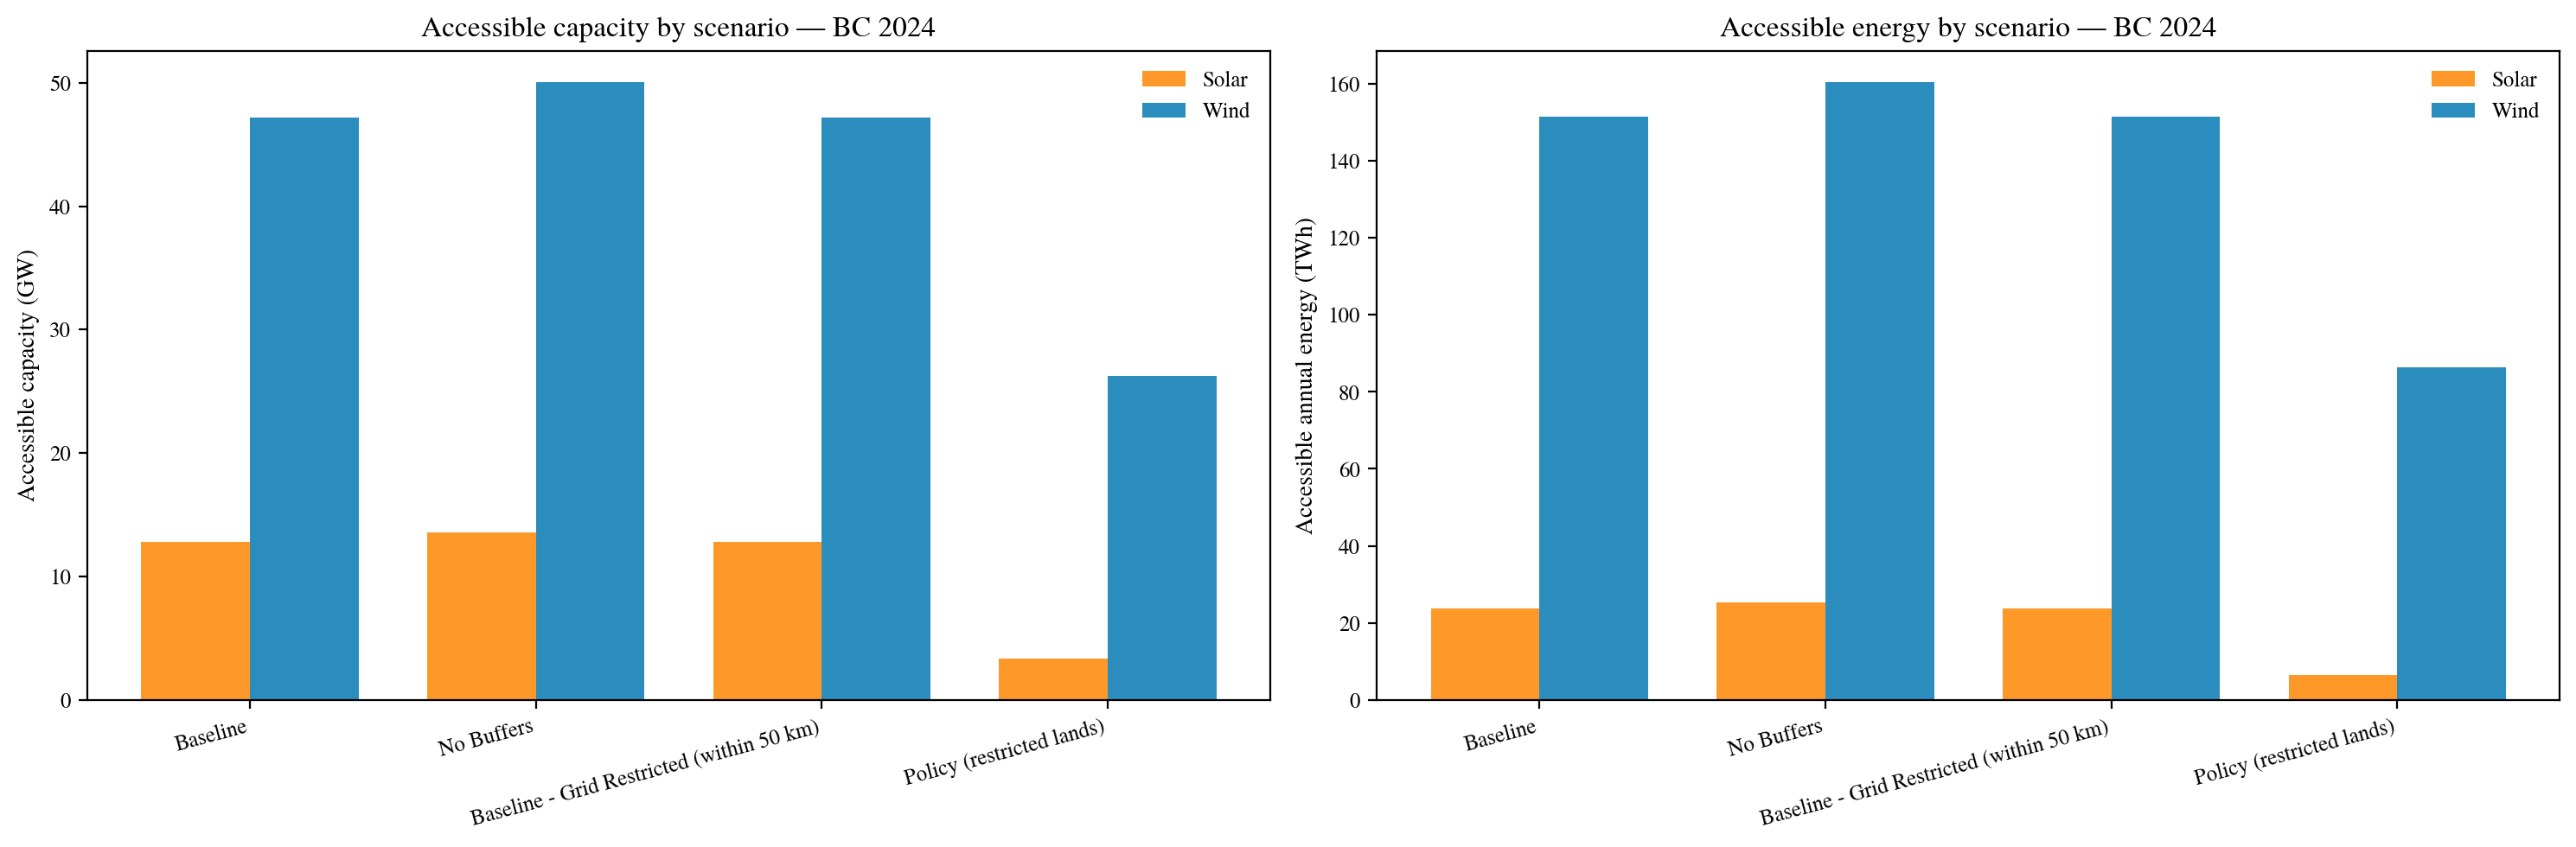

In [19]:
fig, (axc, axe) = plt.subplots(1, 2, figsize=(15, 5), dpi=200)
labels = list(summary.index)
x = np.arange(len(labels)); w = 0.38

axc.bar(x - w/2, summary['solar_accessible_GW'], w, label='Solar', color='#FE9929')
axc.bar(x + w/2, summary['wind_accessible_GW'],  w, label='Wind',  color='#2B8CBE')
axc.set_xticks(x); axc.set_xticklabels(labels, rotation=15, ha='right')
axc.set_ylabel('Accessible capacity (GW)')
axc.set_title(f'Accessible capacity by scenario \u2014 BC {WEATHER_YEAR}')
axc.legend(frameon=False)

axe.bar(x - w/2, energy_summary['solar_accessible_TWh'], w, label='Solar', color='#FE9929')
axe.bar(x + w/2, energy_summary['wind_accessible_TWh'],  w, label='Wind',  color='#2B8CBE')
axe.set_xticks(x); axe.set_xticklabels(labels, rotation=15, ha='right')
axe.set_ylabel('Accessible annual energy (TWh)')
axe.set_title(f'Accessible energy by scenario \u2014 BC {WEATHER_YEAR}')
axe.legend(frameon=False)

fig.tight_layout()
fig.savefig(vis_dir / 'scenario_accessible_bars.png', dpi=300, bbox_inches='tight')
plt.show()

## Scenario table for the manuscript (Table 5 rows)
Formats the accessible capacity and energy summary for direct insertion into the paper.

In [20]:
manuscript_table = summary.join(energy_summary, how='outer')
keep = [c for c in [
    'solar_accessible_GW', 'solar_accessible_TWh', 'solar_acc_delta_pct_vs_BASE',
    'wind_accessible_GW',  'wind_accessible_TWh',  'wind_acc_delta_pct_vs_BASE',
] if c in manuscript_table.columns]
manuscript_table = manuscript_table[keep]
manuscript_table.to_csv(results_dir / 'scenario_manuscript_table.csv')
print(manuscript_table.to_string())
print('\nSaved:', results_dir / 'scenario_manuscript_table.csv')

                                           solar_accessible_GW  solar_accessible_TWh  wind_accessible_GW  wind_accessible_TWh
scenario                                                                                                                     
Baseline                                                12.793                 23.75              47.164               151.51
Baseline - Grid Restricted (within 50 km)               12.793                 23.75              47.164               151.51
No Buffers                                              13.586                 25.23              50.077               160.56
Policy (restricted lands)                                3.299                  6.33              26.243                86.48

Saved: /local-scratch/localhome/mei3/eliasinul/work/RESource/notebooks/Publication_resources/results/Canada/BC/scenarios_2024/scenario_manuscript_table.csv
